# LightGBM Forecasting Model

## Business Objective

The objective of this notebook is to build a LightGBM regression model capable of forecasting burger sales using weather variables, engineered calendar features, and historical sales information.

LightGBM serves as the baseline machine learning model before developing the LSTM deep learning model.

In [433]:
# ==========================================================
# LightGBM Model
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [434]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("../data/burger_data_engineered.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Region,Temperature,Humidity,Wind,Visibility,Pressure,Sales,Year,Month,Day,DayOfWeek,Quarter,WeekOfYear,IsWeekend,Sales_Lag_1,Sales_Lag_7,Sales_Lag_30,Rolling_Mean_7,Rolling_Mean_30,Rolling_STD_7
0,2014-01-03,Reg2,18.174600,0.435980,24.228756,13.744171,1016.652700,992.37,2014,1,3,4,1,1,0,204.32,699.35,1539.45,1581.357143,1639.600333,1291.820530
1,2014-01-04,Reg10,21.861622,0.402545,11.281557,4.461844,1023.733652,23.83,2014,1,4,5,1,1,1,992.37,2774.98,2721.81,1623.217143,1621.364333,1262.900440
2,2014-01-04,Reg8,3.776241,0.886265,5.661404,9.982186,1020.505489,672.21,2014,1,4,5,1,1,1,23.83,950.34,2240.22,1230.195714,1531.431667,1272.774252
3,2014-01-04,Reg3,0.196468,0.829441,5.494188,8.846484,1024.717837,664.99,2014,1,4,5,1,1,1,672.21,405.83,468.78,1190.462857,1479.164667,1287.225940
4,2014-01-04,Reg9,23.463183,0.724208,10.477588,11.057665,1010.657532,2765.08,2014,1,4,5,1,1,1,664.99,3087.19,137.76,1227.485714,1485.705000,1264.422258


In [435]:
# ==========================================================
# Load Saved Objects
# ==========================================================

encoder = joblib.load("../models/region_encoder.pkl")

scaler = joblib.load("../models/quantile_scaler.pkl")

print("Encoder and Scaler Loaded Successfully!")

Encoder and Scaler Loaded Successfully!


In [436]:
try:
    df["Region"] = encoder.transform(df["Region"])
except ValueError:
    region_digits = df["Region"].astype(str).str.extract(r"(\d+)", expand=False)
    if region_digits.isna().any():
        df["Region"], _ = pd.factorize(df["Region"])
    else:
        try:
            df["Region"] = encoder.transform(region_digits.astype(int))
        except ValueError:
            df["Region"], _ = pd.factorize(df["Region"])

X = df.drop(
    columns=[
        "Sales",
        "Date"
    ]
)

y = df["Sales"]

train_size = int(len(df) * 0.70)

validation_size = int(len(df) * 0.15)

X_train = X.iloc[:train_size]
X_validation = X.iloc[
    train_size:
    train_size + validation_size
]
X_test = X.iloc[
    train_size + validation_size:
]

y_train = y.iloc[:train_size]
y_validation = y.iloc[
    train_size:
    train_size + validation_size
]
y_test = y.iloc[
    train_size + validation_size:
]

X_train = scaler.transform(X_train)

X_validation = scaler.transform(X_validation)

X_test = scaler.transform(X_test)

In [437]:
# ==========================================================
# Train LightGBM
# ==========================================================

model = LGBMRegressor(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=8,

    num_leaves=31,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

model.fit(

    X_train,

    y_train,

    eval_set=[(X_validation, y_validation)]
)

print("Model Training Complete!")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001661 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2937
[LightGBM] [Info] Number of data points in the train set: 17095, number of used features: 19
[LightGBM] [Info] Start training from score 1884.847861
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Model Training Complete!


In [438]:
# Predictions
train_predictions = model.predict(X_train)

validation_predictions = model.predict(X_validation)

test_predictions = model.predict(X_test)

In [439]:
# ==========================================================
# Evaluation Function
# ==========================================================

def evaluate_model(actual, predicted, dataset_name):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(mean_squared_error(actual, predicted))

    r2 = r2_score(actual, predicted)

    mape = np.mean(
        np.abs((actual - predicted) / actual)
    ) * 100

    print("=" * 50)

    print(dataset_name)

    print("=" * 50)

    print(f"MAE  : {mae:.2f}")

    print(f"RMSE : {rmse:.2f}")

    print(f"R²   : {r2:.4f}")

    print(f"MAPE : {mape:.2f}%")

In [440]:
evaluate_model(
    y_train,
    train_predictions,
    "Training Set"
)

evaluate_model(
    y_validation,
    validation_predictions,
    "Validation Set"
)

evaluate_model(
    y_test,
    test_predictions,
    "Testing Set"
)

Training Set
MAE  : 266.75
RMSE : 361.59
R²   : 0.8892
MAPE : 185.00%
Validation Set
MAE  : 345.71
RMSE : 472.12
R²   : 0.8083
MAPE : 488.12%
Testing Set
MAE  : 351.64
RMSE : 476.45
R²   : 0.8085
MAPE : 143.81%


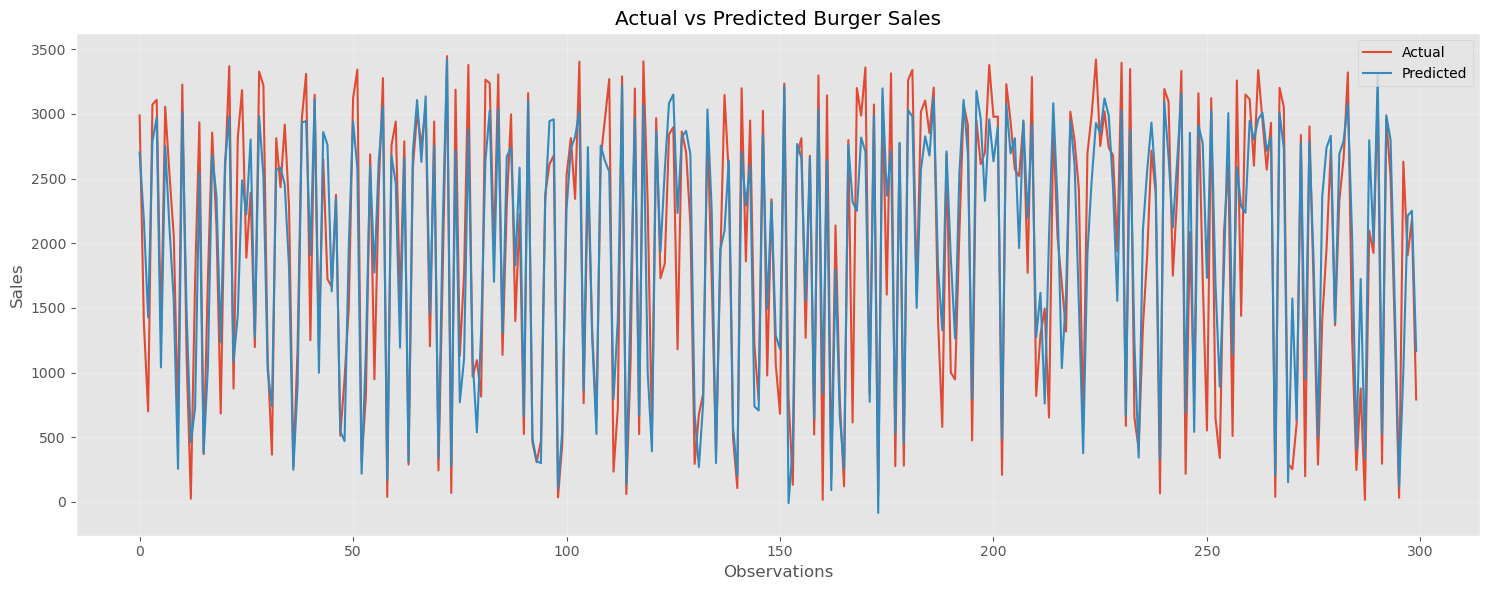

In [441]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values[:300],
    label="Actual"
)

plt.plot(
    test_predictions[:300],
    label="Predicted"
)

plt.title("Actual vs Predicted Burger Sales")

plt.xlabel("Observations")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/lightgbm_predictions.png",
    dpi=300
)

plt.show()

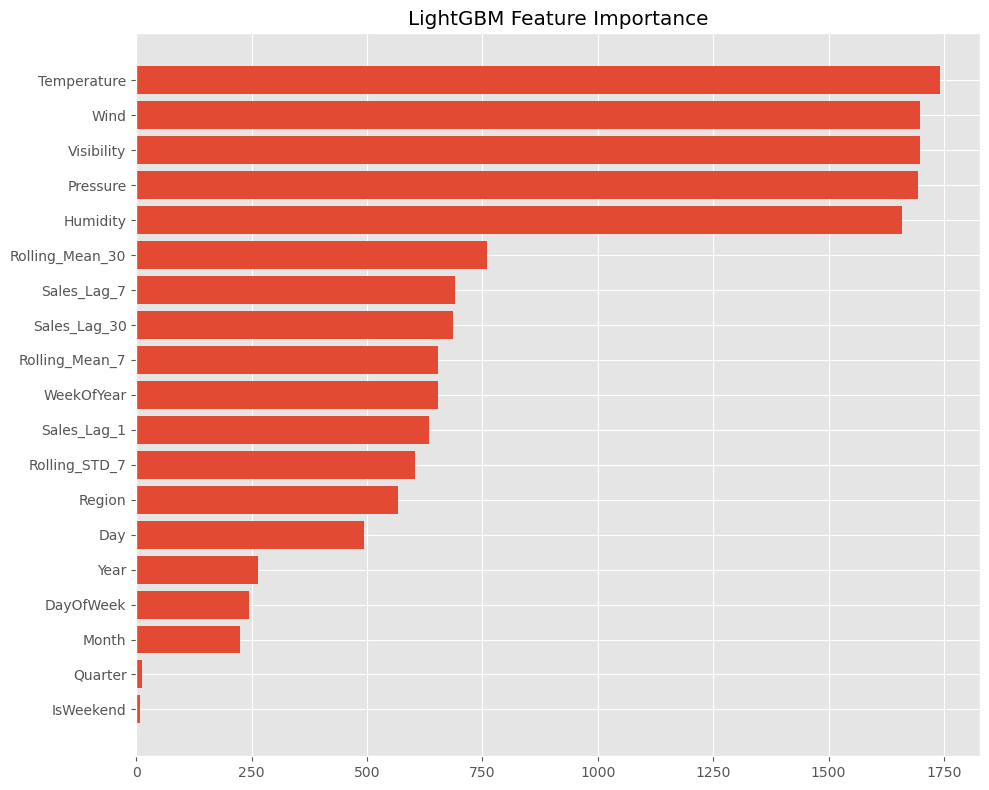

,Feature,Importance
1,Temperature,1741
3,Wind,1699
4,Visibility,1698
5,Pressure,1693
2,Humidity,1660
17,Rolling_Mean_30,761
14,Sales_Lag_7,691
15,Sales_Lag_30,687
16,Rolling_Mean_7,654
11,WeekOfYear,654


In [442]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False
)

plt.figure(figsize=(10,8))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.title("LightGBM Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(

    "../outputs/figures/lightgbm_feature_importance.png",

    dpi=300
)

plt.show()

importance.head(10)

In [443]:
joblib.dump(

    model,

    "../models/lightgbm_model.pkl"

)

print("LightGBM model saved successfully.")

LightGBM model saved successfully.
